In [18]:
# Librerías
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import backend as K
import numpy as np

In [ ]:
class ShmaliyLayer(layers.Layer):
    def __init__(self, units, degree, N=100, **kwargs):
        super(ShmaliyLayer, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.N = float(N) # Parámetro de longitud de datos de Shmaliy

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(self.degree + 1, input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="shmaliy_weights"
        )

    def call(self, inputs):
        # Llevamos la entrada desde [-1, 1] al rango discreto [0, N-1]
        discrete_positions = (inputs + 1.0) * (self.N - 1.0) / 2.0

        # Primeros valores de la recurrencia
        # S0 = 1
        previous_previous_poly = tf.ones_like(discrete_positions)

        # S1 = 1 - (2k)/(N-1)
        previous_poly = 1.0 - (2.0 * discrete_positions) / (self.N - 1.0)

        # Salida inicial con los dos primeros grados
        output_values = (
            tf.matmul(previous_previous_poly, self.w[0]) +
            tf.matmul(previous_poly, self.w[1])
        )

        # Y aqui de forma recursiva al tener los primeros calculamos el resto de términos hasta el grado deseado
        for degree_index in range(1, self.degree):
            denominator = (degree_index + 1.0) * (self.N - 1.0 - degree_index)

            recurrence_term = ((2.0 * degree_index + 1.0) * (self.N - 1.0 - 2.0 * discrete_positions)  * previous_poly) / denominator

            correction_term = (degree_index * (self.N + degree_index)* previous_previous_poly) / denominator

            current_poly = recurrence_term - correction_term

            # Añadimos la contribución del nuevo grado
            output_values += tf.matmul(current_poly, self.w[degree_index + 1])

            # Actualizamos
            previous_previous_poly = previous_poly
            previous_poly = current_poly

        return output_values

In [20]:
# ===== FUNCIÓN DE PLOTEO =====
def plot_training_history_Shm(history_Shm):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history_Shm.history['loss'], label='Pérdida entrenamiento')
    plt.plot(history_Shm.history['val_loss'], label='Pérdida validación')
    plt.title('Pérdida')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history_Shm.history['accuracy'], label='Precisión entrenamiento')
    plt.plot(history_Shm.history['val_accuracy'], label='Precisión validación')
    plt.title('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()



In [21]:

# ===== DATOS =====
magic_gamma_telescope_Shm = fetch_ucirepo(id=159)

X_Shm = magic_gamma_telescope_Shm.data.features 
y_Shm = magic_gamma_telescope_Shm.data.targets 

X_train_Shm, X_test_Shm, y_train_Shm, y_test_Shm = train_test_split( X_Shm, y_Shm, test_size=0.2, random_state=42)

scaler_Shm = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled_Shm = scaler_Shm.fit_transform(X_train_Shm)
X_test_scaled_Shm = scaler_Shm.transform(X_test_Shm)

input_dim_Shm = X_train_Shm.shape[1]

y_train_Shm = (y_train_Shm == 'g').astype(int)
y_test_Shm = (y_test_Shm == 'g').astype(int)


In [22]:
# ===== MODELO =====
def PolynomialDenseCreator_Shm(degree_Shm,nValues_Shm,input_dim_Shm):
    inputPoli_Shm = keras.Input(shape=(input_dim_Shm,))
    
    x_Shm = ShmaliyLayer(32, degree=degree_Shm, N=nValues_Shm)(inputPoli_Shm)
    x_Shm = layers.Activation('swish')(x_Shm)
    x_Shm = layers.Dense(16, activation='swish')(x_Shm)
    
    outputPoli_Shm = layers.Dense(2, activation='softmax')(x_Shm)
    
    model_Shm = keras.Model(
        inputs=inputPoli_Shm,
        outputs=outputPoli_Shm,
        name=f"Polynomial_Model_Degree_{degree_Shm}_Shm"
    )
    
    model_Shm.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model_Shm


In [23]:
def createEarlyStoppingCallback_Shm(patience_Shm=15):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_Shm,
        restore_best_weights=True
    )


In [24]:
# ===== PARÁMETROS =====
degree_Shm = 7
epochs_Shm = 200

In [25]:

# --- 3. CONFIGURACIÓN DE LA BÚSQUEDA ---
from sklearn.model_selection import StratifiedKFold


N_candidates = [25, 50, 100, 250, 500] # Valores de N a probar
n_splits = 5 # Usamos 5 folds para no alargar demasiado la búsqueda
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1)

# Diccionario para almacenar resultados: {grado: {N: accuracy_promedio}}


# Asegurar datos en numpy
X_np = X_Shm.to_numpy() if hasattr(X_Shm, 'to_numpy') else X_Shm
y_np = y_Shm.to_numpy() if hasattr(y_Shm, 'to_numpy') else y_Shm

degree_Results = []

print(f"\n>>> Optimizando N para Grado {degree_Shm} <<<")

for n_val in N_candidates:
    fold_accs = []
    print(f"  Probando N = {n_val}: ", end="")
    i = 0
    
    for train_idx, test_idx in skf.split(X_np, y_np):
        # Limpieza de memoria
        tf.keras.backend.clear_session()
        
        # Split y Normalización
        X_train, X_test = X_np[train_idx], X_np[test_idx]
        y_train, y_test = y_np[train_idx], y_np[test_idx]
        
        scaler = MinMaxScaler(feature_range=(-1, 1))
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        y_train_bin = (y_train == 'g').astype(int)
        y_test_bin = (y_test == 'g').astype(int)
        
        # Modelo
        model = PolynomialDenseCreator_Shm(degree_Shm, n_val, X_np.shape[1])
        
        # Entrenamiento rápido para búsqueda
        model.fit(
            X_train_scaled, y_train_bin,
            epochs=60,
            batch_size=64,
            verbose=0,callbacks=[createEarlyStoppingCallback_Shm(patience_Shm=10)],
            validation_split=0.1
        )
        
        # Evaluación
        _, acc = model.evaluate(X_test_scaled, y_test_bin, verbose=0)
        fold_accs.append(acc)
        print(".", end="", flush=True)
        
    avg_acc = np.mean(fold_accs)
    degree_Results.append(avg_acc)
    i = i + 1
    print(f" Accuracy: {avg_acc:.4f}")

# --- 5. RESULTADOS FINALES ---
print("\n" + "="*40)
print("MEJORES VALORES DE N ENCONTRADOS")
print("="*40)


# Encontrar el N con el accuracy máximo para este grado
best_n = np.argmax(degree_Results)
nvalues_Shm = N_candidates[best_n]
print(f"Grado {degree_Shm}: Mejor N = {nvalues_Shm} (Accuracy: {max(degree_Results):.4f})")


>>> Optimizando N para Grado 7 <<<
  Probando N = 25: ..... Accuracy: 0.8674
  Probando N = 50: ..... Accuracy: 0.8601
  Probando N = 100: ..... Accuracy: 0.8665
  Probando N = 250: ..... Accuracy: 0.8620
  Probando N = 500: ..... Accuracy: 0.8605

MEJORES VALORES DE N ENCONTRADOS
Grado 7: Mejor N = 25 (Accuracy: 0.8674)


Entrenando Grado 7 (Shmaliy) ...
Epoch 1/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8070 - loss: 0.4244 - val_accuracy: 0.8449 - val_loss: 0.3574
Epoch 2/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8546 - loss: 0.3492 - val_accuracy: 0.8512 - val_loss: 0.3571
Epoch 3/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8604 - loss: 0.3419 - val_accuracy: 0.8591 - val_loss: 0.3350
Epoch 4/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8635 - loss: 0.3347 - val_accuracy: 0.8597 - val_loss: 0.3345
Epoch 5/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8654 - loss: 0.3312 - val_accuracy: 0.8617 - val_loss: 0.3294
Epoch 6/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8641 - loss: 0.3277 - val_accuracy: 0.8633 - val_loss: 0.3234
Epoch 7/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8646 - loss: 0.3269 - val_accuracy: 0.8561 - val_loss: 0.3364
Epoch 8/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy:

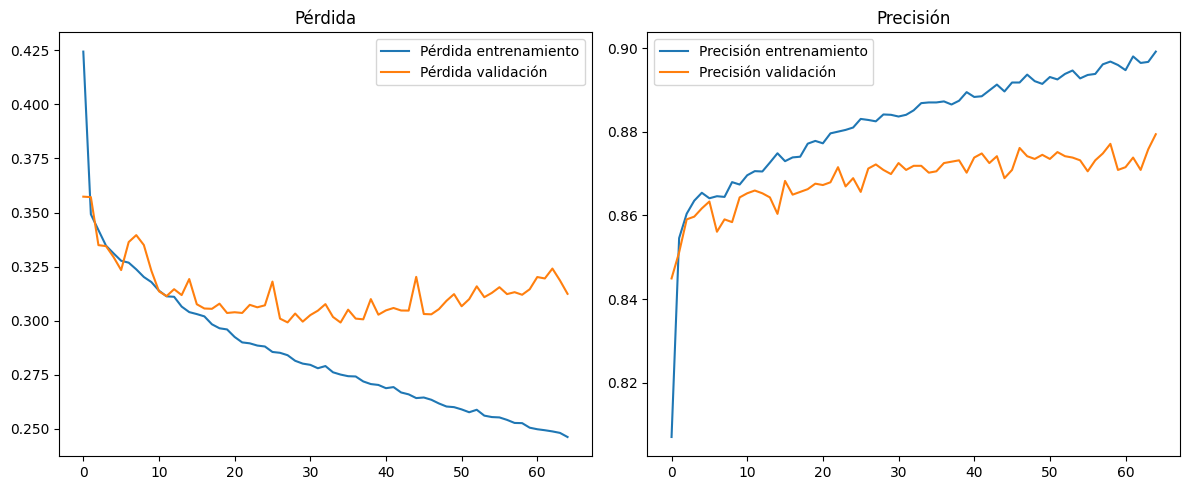

In [26]:

# ===== ENTRENAMIENTO =====
K.clear_session()

print("Entrenando Grado " + str(degree_Shm) + " (Shmaliy) ...")

modeloTest_Shm = PolynomialDenseCreator_Shm(degree_Shm, nvalues_Shm, X_train_scaled_Shm.shape[1])

history_Shm = modeloTest_Shm.fit(
    X_train_scaled_Shm,
    y_train_Shm,
    validation_split=0.2,
    epochs=epochs_Shm,
    callbacks=[createEarlyStoppingCallback_Shm(patience_Shm=30)],
    batch_size=32
)

print("\n" + "="*40)
print(f"RESULTADOS FINALES (Grado {degree_Shm} - Shmaliy)")

acc_Shm = modeloTest_Shm.evaluate(X_test_scaled_Shm,y_test_Shm,verbose=0)[1]

print("Accuracy en test: {:.6f}".format(acc_Shm))

plot_training_history_Shm(history_Shm)